In [1]:
!pip install torch torchvision matplotlib


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
import matplotlib.pyplot as plt


eager 11.66527795791626
aot_eager 12.008602857589722
inductor 24.46941566467285


skipping cudagraphs due to skipping cudagraphs due to cpu device (primals_1). Found from : 
   File "/tmp/ipykernel_691/3929582026.py", line 15, in forward
    return self.net(x)



cudagraphs 8.670977354049683


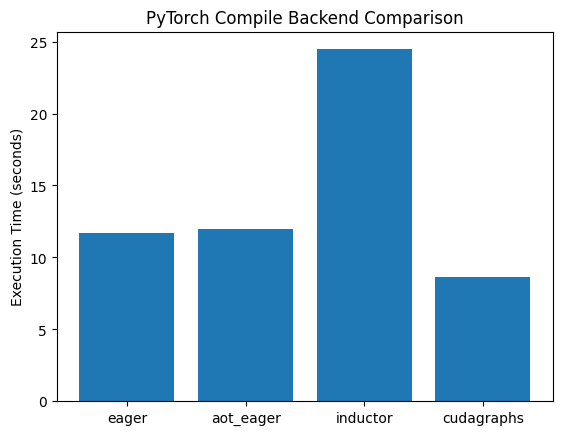

In [4]:
class SimpleNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(512,1024),
            nn.ReLU(),
            nn.Linear(1024,512),
            nn.ReLU(),
            nn.Linear(512,10)
        )

    def forward(self,x):
        return self.net(x)
device = "cuda" if torch.cuda.is_available() else "cpu"

model = SimpleNet().to(device)

x = torch.randn(1024,512).to(device)
y = torch.randn(1024,10).to(device)

loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters())
def benchmark(model):

    start = time.time()

    for _ in range(100):

        optimizer.zero_grad()

        out = model(x)

        loss = loss_fn(out,y)

        loss.backward()

        optimizer.step()

    if device == "cuda":
        torch.cuda.synchronize()

    return time.time() - start

backends = [
    "eager",
    "aot_eager",
    "inductor",
    "cudagraphs"
]

times = []

for b in backends:

    if b == "eager":
        m = SimpleNet().to(device)

    else:
        m = torch.compile(SimpleNet().to(device),backend=b)

    t = benchmark(m)

    times.append(t)

    print(b,t)

plt.bar(backends,times)

plt.title("PyTorch Compile Backend Comparison")

plt.ylabel("Execution Time (seconds)")

plt.show()


In [6]:
def problem1(x):

    if x.sum() > 0:
        return x * 2
    else:
        return x / 2

compiled = torch.compile(problem1)

compiled(torch.randn(10))

torch._dynamo.explain(problem1, torch.randn(10))


/usr/lib/python3.12/unittest/mock.py:1396: FutureWarning: explain(f, *args, **kwargs) is deprecated, use explain(f)(*args, **kwargs) instead.  If you don't migrate, we may break your explain call in the future if your user defined kwargs conflict with future kwargs added to explain(f).
  return func(*newargs, **newkeywargs)


ExplainOutput(graphs=[GraphModule(), GraphModule()], graph_count=2, graph_break_count=1, break_reasons=[GraphCompileReason(reason='generic_jump TensorVariable()', user_stack=[<FrameSummary file /tmp/ipykernel_691/4049105372.py, line 3 in problem1>], graph_break=True)], op_count=2, ops_per_graph=[[<built-in function gt>], [<built-in function mul>]], out_guards=[
        shape_env '' SHAPE_ENV
        {
            'guard_types': None,
            'code': None,
            'obj_weakref': None
            'guarded_class': None
        }
        , 
        global '' DETERMINISTIC_ALGORITHMS
        {
            'guard_types': None,
            'code': None,
            'obj_weakref': None
            'guarded_class': None
        }
        , 
        global '' GRAD_MODE
        {
            'guard_types': None,
            'code': None,
            'obj_weakref': None
            'guarded_class': None
        }
        , 
        global '' DEFAULT_DEVICE
        {
            'guard_type

In [7]:
def fixed_problem1(x):

    cond = torch.sum(x)

    return torch.where(cond > 0, x * 2, x / 2)
compiled = torch.compile(fixed_problem1)

compiled(torch.randn(10))


tensor([ 1.4392,  1.9516,  1.8396, -2.9632,  5.5760,  0.0826, -0.9004,  2.5356,
        -0.2779,  1.7685])

In [9]:
def problem2(x):

    d = {}

    d["key"] = x

    return d["key"] * 2
compiled = torch.compile(problem2)

compiled(torch.randn(10))
torch._dynamo.explain(problem2, torch.randn(10))


ExplainOutput(graphs=[GraphModule()], graph_count=1, graph_break_count=0, break_reasons=[], op_count=1, ops_per_graph=[[<built-in function mul>]], out_guards=[
        shape_env '' SHAPE_ENV
        {
            'guard_types': None,
            'code': None,
            'obj_weakref': None
            'guarded_class': None
        }
        , 
        global '' DETERMINISTIC_ALGORITHMS
        {
            'guard_types': None,
            'code': None,
            'obj_weakref': None
            'guarded_class': None
        }
        , 
        global '' GRAD_MODE
        {
            'guard_types': None,
            'code': None,
            'obj_weakref': None
            'guarded_class': None
        }
        , 
        global '' DEFAULT_DEVICE
        {
            'guard_types': ['DEFAULT_DEVICE'],
            'code': ['utils_device.CURRENT_DEVICE == None'],
            'obj_weakref': None
            'guarded_class': None
        }
        , 
        global '' GLOBAL_STATE
 

In [10]:
def fixed_problem2(x):

    return x * 2
compiled = torch.compile(fixed_problem2)

compiled(torch.randn(10))


tensor([-0.3943,  1.1458, -1.3116, -4.0485,  1.9143, -1.6916,  5.4921, -2.4256,
         2.2694, -3.3775])

In [11]:
def problem3(x):

    result = 0

    for i in range(10):
        result += (x ** i).sum()

    return result
compiled = torch.compile(problem3)

compiled(torch.randn(10))
torch._dynamo.explain(problem3, torch.randn(10))


/usr/lib/python3.12/unittest/mock.py:1396: FutureWarning: explain(f, *args, **kwargs) is deprecated, use explain(f)(*args, **kwargs) instead.  If you don't migrate, we may break your explain call in the future if your user defined kwargs conflict with future kwargs added to explain(f).
  return func(*newargs, **newkeywargs)


ExplainOutput(graphs=[GraphModule()], graph_count=1, graph_break_count=0, break_reasons=[], op_count=20, ops_per_graph=[[<built-in function pow>, <built-in function add>, <built-in function pow>, <built-in function iadd>, <built-in function pow>, <built-in function iadd>, <built-in function pow>, <built-in function iadd>, <built-in function pow>, <built-in function iadd>, <built-in function pow>, <built-in function iadd>, <built-in function pow>, <built-in function iadd>, <built-in function pow>, <built-in function iadd>, <built-in function pow>, <built-in function iadd>, <built-in function pow>, <built-in function iadd>]], out_guards=[
        shape_env '' SHAPE_ENV
        {
            'guard_types': None,
            'code': None,
            'obj_weakref': None
            'guarded_class': None
        }
        , 
        global '' DETERMINISTIC_ALGORITHMS
        {
            'guard_types': None,
            'code': None,
            'obj_weakref': None
            'guarded_cla

In [12]:
def fixed_problem3(x):

    powers = torch.stack([x**i for i in range(10)])

    return powers.sum()
compiled = torch.compile(fixed_problem3)

compiled(torch.randn(10))


tensor(61.0711)

In [13]:
def graph_example(x, w1, w2):

    y = x @ w1

    y = torch.relu(y)

    y = y @ w2

    y = y + x

    y = torch.nn.functional.layer_norm(y, y.shape)

    print("Hello")

    lst = []
    lst.append(1)

    return y


In [14]:
compiled = torch.compile(graph_example)

x = torch.randn(32,64)
w1 = torch.randn(64,64)
w2 = torch.randn(64,64)

compiled(x,w1,w2)


Hello


tensor([[ 0.6986, -0.3004, -0.3045,  ..., -0.3635, -1.1266, -0.8022],
        [-0.8841,  1.3224,  0.1719,  ..., -0.5445, -0.3381,  1.0537],
        [-0.1020,  0.6480,  1.5790,  ..., -0.0644, -0.1388, -0.1121],
        ...,
        [ 0.1452, -0.0756, -1.1174,  ..., -0.5949, -2.4147, -1.6193],
        [-0.7244, -0.2958, -0.5391,  ..., -0.2032, -0.6128, -0.8489],
        [-1.0038,  0.2124,  0.2976,  ..., -1.5676, -0.7637,  0.4031]])

In [15]:
torch._dynamo.explain(graph_example)(x, w1, w2)


Hello


ExplainOutput(graphs=[GraphModule()], graph_count=1, graph_break_count=0, break_reasons=[GraphCompileReason(reason="Failed to trace builtin operator\n  Explanation: Dynamo does not know how to trace builtin operator `print` with argument types ['str'] (has_kwargs False)\n  Hint: Avoid calling builtin `print` with argument types ['str']. Consider using an equivalent alternative function/method to `print`.\n  Hint: If you are attempting to call a logging function (e.g. `print`), you can try adding it to `torch._dynamo.config.reorderable_logging_functions`.\n  Hint: Please report an issue to PyTorch.\n\n  Developer debug context: builtin print [<class 'torch._dynamo.variables.constant.ConstantVariable'>] False\n\n For more details about this graph break, please visit: https://meta-pytorch.github.io/compile-graph-break-site/gb/gb0059.html", user_stack=[<FrameSummary file /tmp/ipykernel_691/1293483982.py, line 13 in graph_example>], graph_break=True)], op_count=5, ops_per_graph=[[<built-in 

In [16]:
from torch.fx import symbolic_trace

traced = symbolic_trace(graph_example)

print(traced.graph)


Hello
graph():
    %x : [num_users=2] = placeholder[target=x]
    %w1 : [num_users=1] = placeholder[target=w1]
    %w2 : [num_users=1] = placeholder[target=w2]
    %matmul : [num_users=1] = call_function[target=operator.matmul](args = (%x, %w1), kwargs = {})
    %relu : [num_users=1] = call_function[target=torch.relu](args = (%matmul,), kwargs = {})
    %matmul_1 : [num_users=1] = call_function[target=operator.matmul](args = (%relu, %w2), kwargs = {})
    %add : [num_users=2] = call_function[target=operator.add](args = (%matmul_1, %x), kwargs = {})
    %getattr_1 : [num_users=1] = call_function[target=builtins.getattr](args = (%add, shape), kwargs = {})
    %layer_norm : [num_users=1] = call_function[target=torch.nn.functional.layer_norm](args = (%add, %getattr_1), kwargs = {weight: None, bias: None, eps: 1e-05})
    return layer_norm
